# Step 0: Install Required Libraries and Import Dependencies
In this step, we import all the necessary libraries for data processing, deep learning, and machine learning.

In [1]:
# pip install nibabel
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# Step 1: Data Loading and Preprocessing
This function loads 3D CT scan files (NIfTI format). We apply Hounsfield Unit (HU) windowing to focus on lung tissues, extract slices from 3 different depths (25%, 50%, 75%) to capture more 3D spatial information, stack them into a 3-channel image, and normalize the values between 0 and 1.

In [2]:
import os
import glob
import numpy as np
import nibabel as nib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tqdm import tqdm # Progress bar library

def load_and_preprocess_nifti(file_path, target_size=(128, 128)):
    # Load 3D NIfTI file
    scan = nib.load(file_path).get_fdata()
    
    # Hounsfield Unit Windowing: Clip values to focus on lung tissues (-1000 to 400)
    scan = np.clip(scan, -1000, 400)
    
    # Extract 3 slices at 25%, 50%, and 75% depth to capture 3D spatial information
    depth = scan.shape[2]
    slice_1 = scan[:, :, int(depth * 0.25)]
    slice_2 = scan[:, :, int(depth * 0.50)]
    slice_3 = scan[:, :, int(depth * 0.75)]
    
    # Stack the slices to create a 3-channel image
    slices = np.stack([slice_1, slice_2, slice_3], axis=-1)
    
    # Min-Max Normalization (scale values to [0, 1])
    slices = (slices - np.min(slices)) / (np.max(slices) - np.min(slices) + 1e-8)
    
    # Resize to the target dimensions (128x128x3)
    return tf.image.resize(slices, target_size).numpy()

dataset_path = '/kaggle/input/datasets/mathurinache/mosmeddata-chest-ct-scans-with-covid19/MosMedData Chest CT Scans with COVID-19 Related Findings COVID19_1110 1.0/studies'
file_paths = glob.glob(os.path.join(dataset_path, '**', '*.nii*'), recursive=True)

X_data = []
y_data = []

print(f"Total files found: {len(file_paths)}")
print("Processing images...")

# Iterate through all file paths with a progress bar
for path in tqdm(file_paths, desc="Processing CT Scans", unit="file"):
    try:
        # Extract label from the folder name (CT-0 to CT-4)
        folder_name = os.path.basename(os.path.dirname(path))
        if "CT-0" in folder_name: label = 0
        elif "CT-1" in folder_name: label = 1
        elif "CT-2" in folder_name: label = 2
        elif "CT-3" in folder_name: label = 3
        elif "CT-4" in folder_name: label = 4
        else: continue 
            
        img = load_and_preprocess_nifti(path)
        X_data.append(img)
        y_data.append(label)
    except Exception as e:
        # Skip corrupted files
        pass

X = np.array(X_data)
y = np.array(y_data)

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nProcessing completed successfully!")
print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}")


تعداد کل فایل‌های پیدا شده: 1110
در حال پردازش تصاویر... (با الگوریتم بهینه‌شده)


Processing CT Scans:   0%|          | 0/1110 [00:00<?, ?file/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1786262369.662981      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
Processing CT Scans: 100%|██████████| 1110/1110 [03:46<00:00,  4.90file/s]



پردازش با موفقیت تمام شد!
ابعاد داده‌های آموزش: X=(888, 128, 128, 1), y=(888,)
ابعاد داده‌های تست: X=(222, 128, 128, 1), y=(222,)


# Define Metrics and Data Augmentation
Here we define necessary evaluation metrics and a simple data augmentation layer (RandomRotation and RandomZoom) to prevent overfitting. This augmentation layer will be used to create a Denoising Autoencoder.

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (accuracy_score, recall_score, f1_score, 
                             matthews_corrcoef, confusion_matrix, 
                             roc_auc_score, roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize

# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05), # Mild rotation (approx 18 degrees)
    layers.RandomZoom(0.1)       # Mild 10% zoom
], name="data_augmentation")


# Step 2: Design the Autoencoder Architecture
We build an Autoencoder with an Encoder part to compress the image into 256 latent features, and a Decoder part to reconstruct the image. The model has been optimized with Max-Pooling layers to reduce the number of parameters and prevent overfitting.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

input_shape = (128, 128, 3) # 3 channels input

# 1. Encoder Section
encoder_input = layers.Input(shape=input_shape, name="encoder_input")
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # Spatial dimensions reduced to 8x8

# Flattening and Bottleneck Layer (Latent Features)
shape_before_flatten = tf.keras.backend.int_shape(x)[1:]
x = layers.Flatten()(x)
latent_space = layers.Dense(256, activation='relu', name="latent_features")(x) # Extract 256 features

encoder = models.Model(encoder_input, latent_space, name="encoder")

# 2. Decoder Section
decoder_input = layers.Input(shape=(256,), name="decoder_input")
x = layers.Dense(int(np.prod(shape_before_flatten)), activation='relu')(decoder_input)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x) # Reconstruct 3 channels

decoder = models.Model(decoder_input, decoder_output, name="decoder")

# 3. Complete Autoencoder Model
autoencoder_input = layers.Input(shape=input_shape, name="autoencoder_input")

# Connect Encoder and Decoder
encoded_img = encoder(autoencoder_input)
reconstructed_img = decoder(encoded_img)

autoencoder = models.Model(autoencoder_input, reconstructed_img, name="autoencoder")
autoencoder.compile(optimizer='adam', loss='mse')

# Print Model Summary
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 256)            │     8,481,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 1)    │     8,661,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,143,041 (65.40 MB)

 Trainable params: 17,143,041 (65.40 MB)

 Non-trainable params: 0 (0.00 B)

# Step 3: Train Denoising Autoencoder
We train the Autoencoder using early stopping and checkpointing. To make it robust, we create a Denoising Autoencoder mapping pipeline: the input receives data augmentation, but the target to reconstruct is the original image.

شروع آموزش اتوانکدر...
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0413
Epoch 1: val_loss improved from None to 0.01281, saving model to best_autoencoder.keras

Epoch 1: finished saving model to best_autoencoder.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - loss: 0.0251 - val_loss: 0.0128
Epoch 2/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0115
Epoch 2: val_loss improved from 0.01281 to 0.01199, saving model to best_autoencoder.keras

Epoch 2: finished saving model to best_autoencoder.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0117 - val_loss: 0.0120
Epoch 3/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0120
Epoch 3: val_loss improved from 0.01199 to 0.01172, saving model to best_autoencoder.keras

Epoch 3: finished saving model to best_autoencoder.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0111 - val_loss: 0.0117
Epoch 4/50
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0109
Epoch 4: val_loss improved from 0.01172 to 0.0

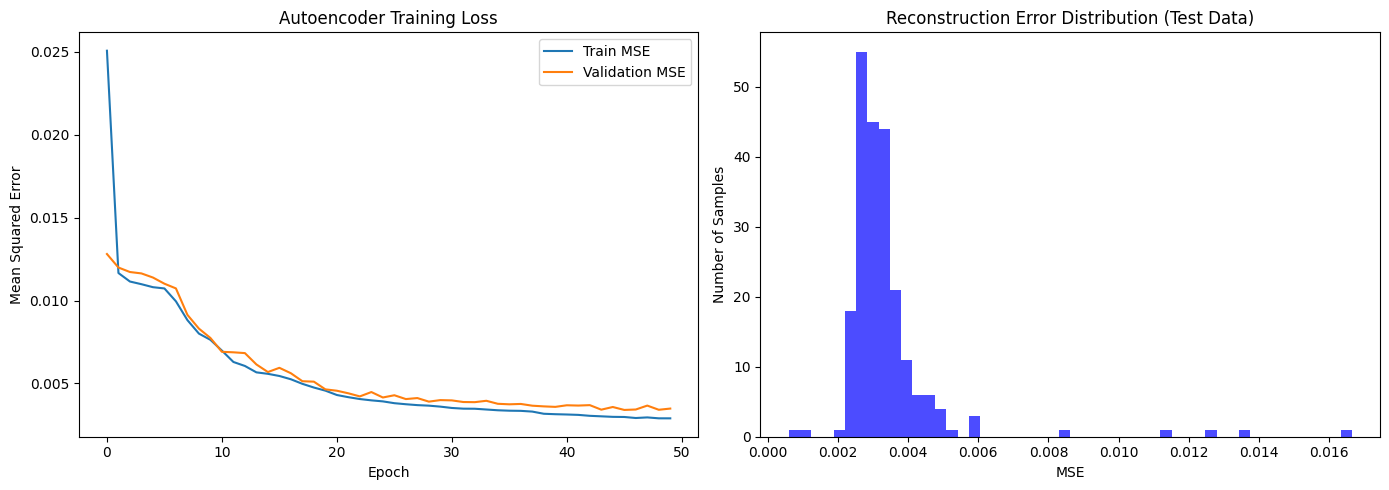

16/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   

I0000 00:00:1786262693.092793     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- 1. Define Callbacks for Autoencoder ---
ae_early_stopping = EarlyStopping(
    monitor='val_loss',       # Monitor validation loss
    patience=7,               # Stop if no improvement for 7 epochs
    restore_best_weights=True # Restore best model weights
)

ae_checkpoint = ModelCheckpoint(
    filepath='best_autoencoder.keras', # Path to save the best model
    monitor='val_loss', 
    save_best_only=True,               # Save only the best model
    verbose=1
)

# --- 2. Create tf.data.Dataset for Denoising Autoencoder ---
# Apply augmentation to input but keep the target original
train_ds = tf.data.Dataset.from_tensor_slices((X_train, X_train))\
    .batch(32)\
    .map(lambda x, y: (data_augmentation(x, training=True), y))

test_ds = tf.data.Dataset.from_tensor_slices((X_test, X_test)).batch(32)

# --- 3. Train the Autoencoder ---
print("Starting Autoencoder training...")
history_ae = autoencoder.fit(
    train_ds,
    epochs=50, 
    validation_data=test_ds,
    callbacks=[ae_early_stopping, ae_checkpoint]
)

# ---- 4. Evaluate Autoencoder: Plot Loss and Reconstruction Error ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
axes[0].plot(history_ae.history['loss'], label='Train MSE')
axes[0].plot(history_ae.history['val_loss'], label='Validation MSE')
axes[0].set_title('Autoencoder Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()

# Histogram of Reconstruction Errors on Test Data
reconstructed_test = autoencoder.predict(X_test)
mse_errors = np.mean(np.square(X_test - reconstructed_test), axis=(1, 2, 3))
axes[1].hist(mse_errors, bins=50, color='blue', alpha=0.7)
axes[1].set_title('Reconstruction Error Distribution (Test Data)')
axes[1].set_xlabel('MSE')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

# Extract features for later stages
X_train_features = encoder.predict(X_train)
X_test_features = encoder.predict(X_test)


# Visualize Reconstructed Images
Let's visualize a few original test images and their reconstructed versions to visually verify the autoencoder's performance.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


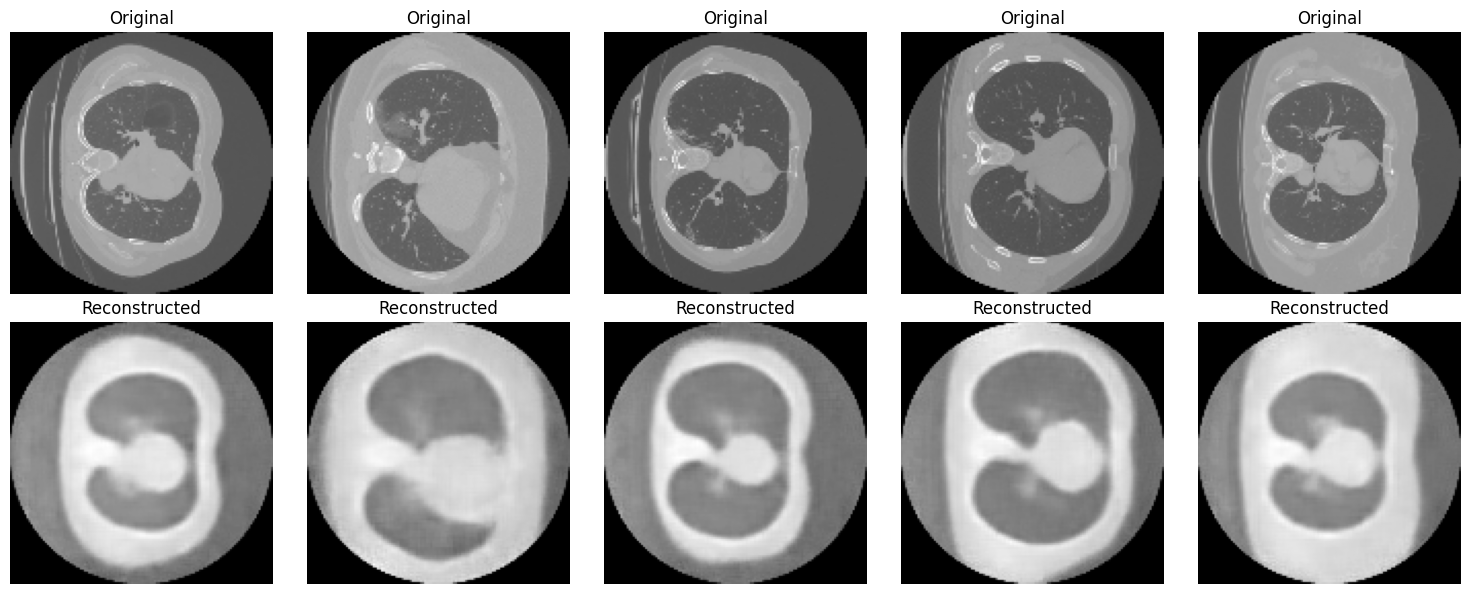

In [6]:
# Predict (Reconstruct) Test Images
reconstructed_imgs = autoencoder.predict(X_test)

# Plot 5 random images: Top row = Original, Bottom row = Reconstructed
n = 5
plt.figure(figsize=(15, 6))
for i in range(n):
    # Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis("off")
    
    # Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.tight_layout()
plt.show()


# Step 4: Extract Features with Encoder
Once the autoencoder is trained, we use its encoder part to compress all images into a 256-dimensional feature vector. These features will act as inputs to our classifiers.

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Shape of extracted features: (888, 256)


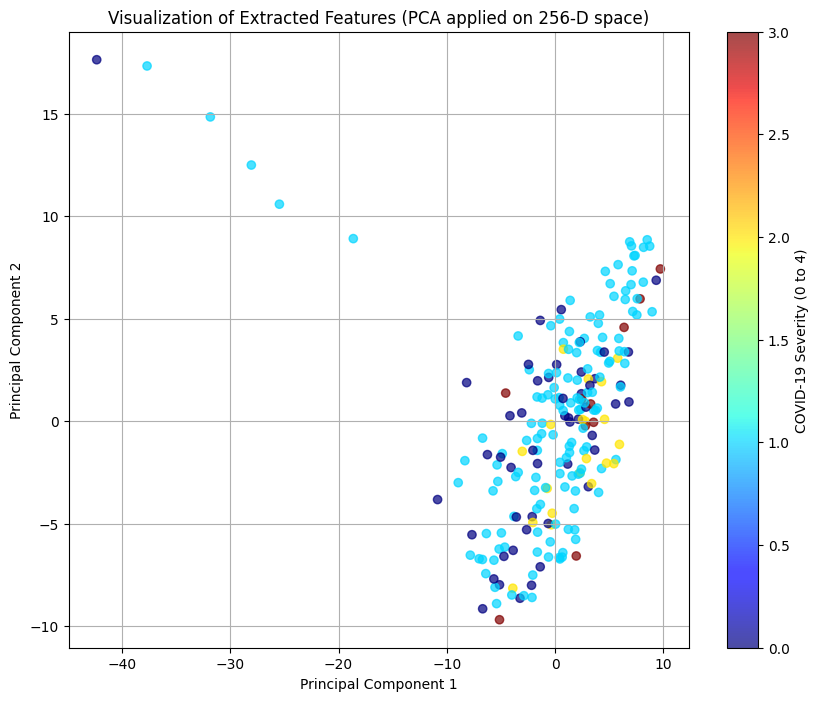

In [7]:
from sklearn.decomposition import PCA

# Extract 256 features using the encoder
X_train_features = encoder.predict(X_train)
X_test_features = encoder.predict(X_test)

print(f"Shape of extracted training features: {X_train_features.shape}")
print(f"Shape of extracted testing features: {X_test_features.shape}")


# Data Balancing
The COVID-19 dataset is likely imbalanced. We use RandomOverSampler to balance the classes in our training set so our classifiers learn all classes equally well.

In [8]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np

# Initialize Data Oversampler
ros = RandomOverSampler(random_state=42)

# Balance the training data
X_train_features_bal, y_train_bal = ros.fit_resample(X_train_features, y_train)

print("Class distribution BEFORE balancing:", np.bincount(y_train))
print("Class distribution AFTER balancing: ", np.bincount(y_train_bal))


📊 توزیع داده‌های آموزش قبل از بالانس:
Class 0: 204 samples
Class 1: 542 samples
Class 2: 105 samples
Class 3: 35 samples
Class 4: 2 samples
----------------------------------------
⚖️ توزیع داده‌های آموزش بعد از بالانس:
Class 0: 542 samples
Class 1: 542 samples
Class 2: 542 samples
Class 3: 542 samples
Class 4: 542 samples


# Comprehensive Evaluation Function
We define a robust function that prints out metrics (Accuracy, Precision, Recall, F1, AUC) and plots the Confusion Matrix, Multi-class ROC Curve, and Precision-Recall Curve to thoroughly evaluate our classifiers.

In [9]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             matthews_corrcoef, confusion_matrix, roc_auc_score, 
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_classifier_comprehensive(y_true, y_pred, y_prob, class_names=None):
    """
    A comprehensive function to evaluate a multi-class classification model.
    """
    n_classes = y_prob.shape[1]
    if class_names is None:
        class_names = [f"Class {i}" for i in range(n_classes)]
        
    labels = list(range(n_classes))
        
    y_true_bin = label_binarize(y_true, classes=labels)
    if n_classes == 2:
        y_true_bin = np.hstack((1 - y_true_bin, y_true_bin))
        
    print("=" * 60)
    print("                      MODEL EVALUATION REPORT                      ")
    print("=" * 60)
    print(f"Accuracy:                  {accuracy_score(y_true, y_pred):.4f}")
    print(f"MCC (Matthews Corr):       {matthews_corrcoef(y_true, y_pred):.4f}")
    print("-" * 60)
    
    print(f"Precision (Macro):         {precision_score(y_true, y_pred, labels=labels, average='macro', zero_division=0):.4f}")
    print(f"Precision (Micro):         {precision_score(y_true, y_pred, labels=labels, average='micro', zero_division=0):.4f}")
    print(f"Recall (Macro):            {recall_score(y_true, y_pred, labels=labels, average='macro', zero_division=0):.4f}")
    print(f"Recall (Micro):            {recall_score(y_true, y_pred, labels=labels, average='micro', zero_division=0):.4f}")
    print(f"F1-Score (Macro):          {f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0):.4f}")
    print(f"F1-Score (Micro):          {f1_score(y_true, y_pred, labels=labels, average='micro', zero_division=0):.4f}")
    print("-" * 60)
    
    print(f"ROC AUC (Macro):           {roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr'):.4f}")
    print(f"ROC AUC (Micro):           {roc_auc_score(y_true_bin, y_prob, average='micro', multi_class='ovr'):.4f}")
    print(f"PR AUC (Macro):            {average_precision_score(y_true_bin, y_prob, average='macro'):.4f}")
    print(f"PR AUC (Micro):            {average_precision_score(y_true_bin, y_prob, average='micro'):.4f}")
    print("=" * 60)
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title('Confusion Matrix', fontsize=14)
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
    axes[0].tick_params(axis='x', rotation=45)
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        axes[1].plot(fpr, tpr, lw=1.5, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')
        
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    axes[1].plot(fpr_micro, tpr_micro, lw=2.5, linestyle=':', color='black', 
                 label=f'Micro-average (AUC = {auc(fpr_micro, tpr_micro):.2f})')
    
    axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[1].set_title('ROC Curve (Multi-class)', fontsize=14)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right", fontsize=9)
    axes[1].grid(alpha=0.3)
    
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        axes[2].plot(recall, precision, lw=1.5, label=f'{class_names[i]}')
        
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
    pr_micro_auc = average_precision_score(y_true_bin, y_prob, average="micro")
    axes[2].plot(recall_micro, precision_micro, lw=2.5, linestyle=':', color='black', 
                 label=f'Micro-average (AUC = {pr_micro_auc:.2f})')
                 
    axes[2].set_title('Precision-Recall Curve', fontsize=14)
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc="lower left", fontsize=9)
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


شروع آموزش شبکه دسته‌بند...
Epoch 1/100
339/339 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3644 - loss: 1.5196
Epoch 1: val_loss improved from None to 1.27479, saving model to best_classifier_nn.keras

Epoch 1: finished saving model to best_classifier_nn.keras
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4399 - loss: 1.2869 - val_accuracy: 0.4099 - val_loss: 1.2748
Epoch 2/100
334/339 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5227 - loss: 1.0598
Epoch 2: val_loss improved from 1.27479 to 1.27009, saving model to best_classifier_nn.keras

Epoch 2: finished saving model to best_classifier_nn.keras
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5387 - loss: 1.0339 - val_accuracy: 0.3964 - val_loss: 1.2701
Epoch 3/100
327/339 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5859 - loss: 0.9571
Epoch 3: val_loss improved from 1.27009 to 1.23481, saving model to best_classifier_nn.keras

Epoch 3: finished saving model to best_classifier_nn.keras
339/339 ━━━━━━━━━━━━━

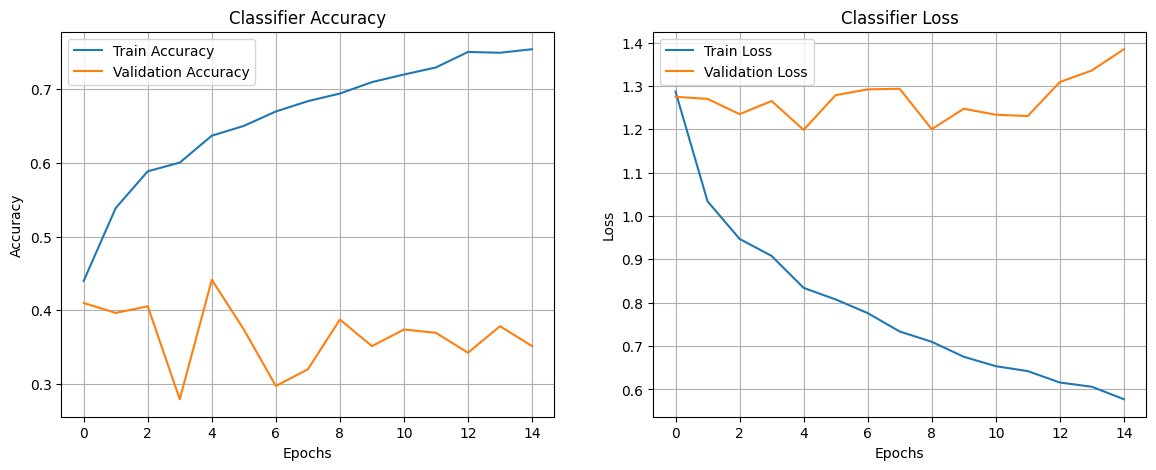

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

>>> 🧠 ارزیابی جامع شبکه عصبی دسته‌بند <<<
 📊 گزارش جامع ارزیابی مدل (Classification Report)
                 precision    recall  f1-score   support

  CT-0 (Normal)     0.3571    0.3000    0.3261        50
    CT-1 (Mild)     0.7000    0.4930    0.5785       142
CT-2 (Moderate)     0.1719    0.5500    0.2619        20
  CT-3 (Severe)     0.1429    0.2000    0.1667        10
CT-4 (Critical)     0.0000    0.0000    0.0000         0

       accuracy                         0.4414       222
      macro avg     0.2744    0.3086    0.2666       222
   weighted avg     0.5501    0.4414    0.4746       222

 🎯 معیارهای کلان (Macro) و خرد (Micro)
Accuracy:                  0.4414
MCC:                       0.1370
------------------------------------------------------------
Precision (Macro):         0.2744
Precision (Micro):         0.4414
Recall (Macro):            0.3086
Recall (Micro):            0.4414
F1-Score (Macro):          0.2666
F1-Score (Micro

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


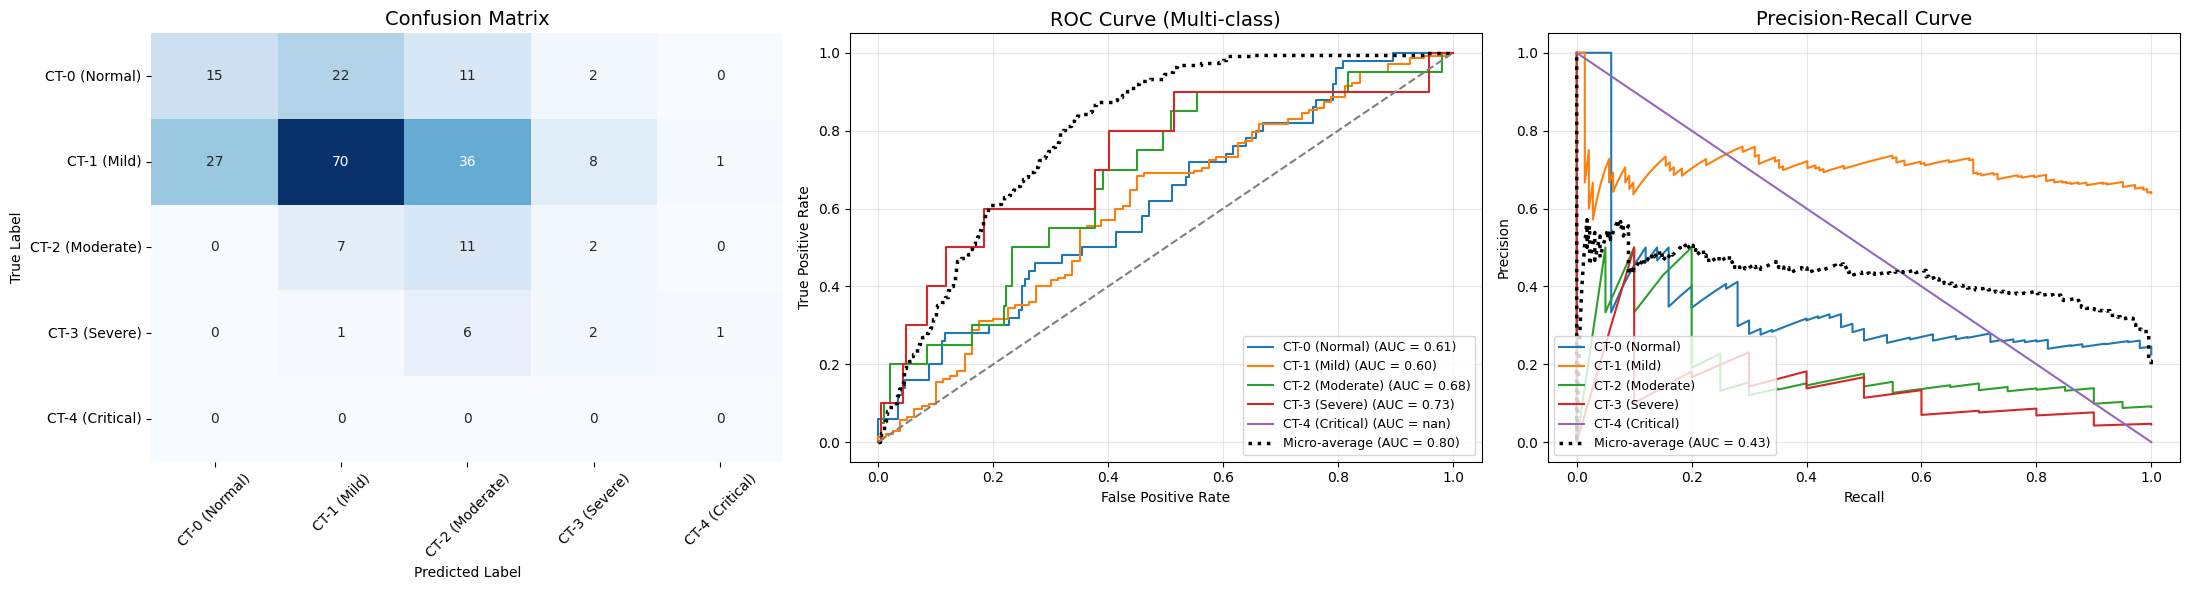

In [10]:
# Step 5: Train Classification Models
We will test two different approaches to classify the extracted features into 5 severity levels (CT-0 to CT-4).

# مرحله ۳: آموزش مدل دسته‌بندی (Classification)

> **Method 1: Random Forest Classifier**
A classical machine learning approach that works very well on extracted features, especially with smaller datasets.

>>> ارزیابی مدل Random Forest <<<
 📊 گزارش جامع ارزیابی مدل (Classification Report)
                 precision    recall  f1-score   support

  CT-0 (Normal)     0.3636    0.2400    0.2892        50
    CT-1 (Mild)     0.6455    0.8592    0.7372       142
CT-2 (Moderate)     0.0000    0.0000    0.0000        20
  CT-3 (Severe)     0.0000    0.0000    0.0000        10
CT-4 (Critical)     0.0000    0.0000    0.0000         0

       accuracy                         0.6036       222
      macro avg     0.2018    0.2198    0.2053       222
   weighted avg     0.4948    0.6036    0.5366       222

 🎯 معیارهای کلان (Macro) و خرد (Micro)
Accuracy:                  0.6036
MCC:                       0.0698
------------------------------------------------------------
Precision (Macro):         0.2018
Precision (Micro):         0.6036
Recall (Macro):            0.2198
Recall (Micro):            0.6036
F1-Score (Macro):          0.2053
F1-Score (Micro):          0.6036
----------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


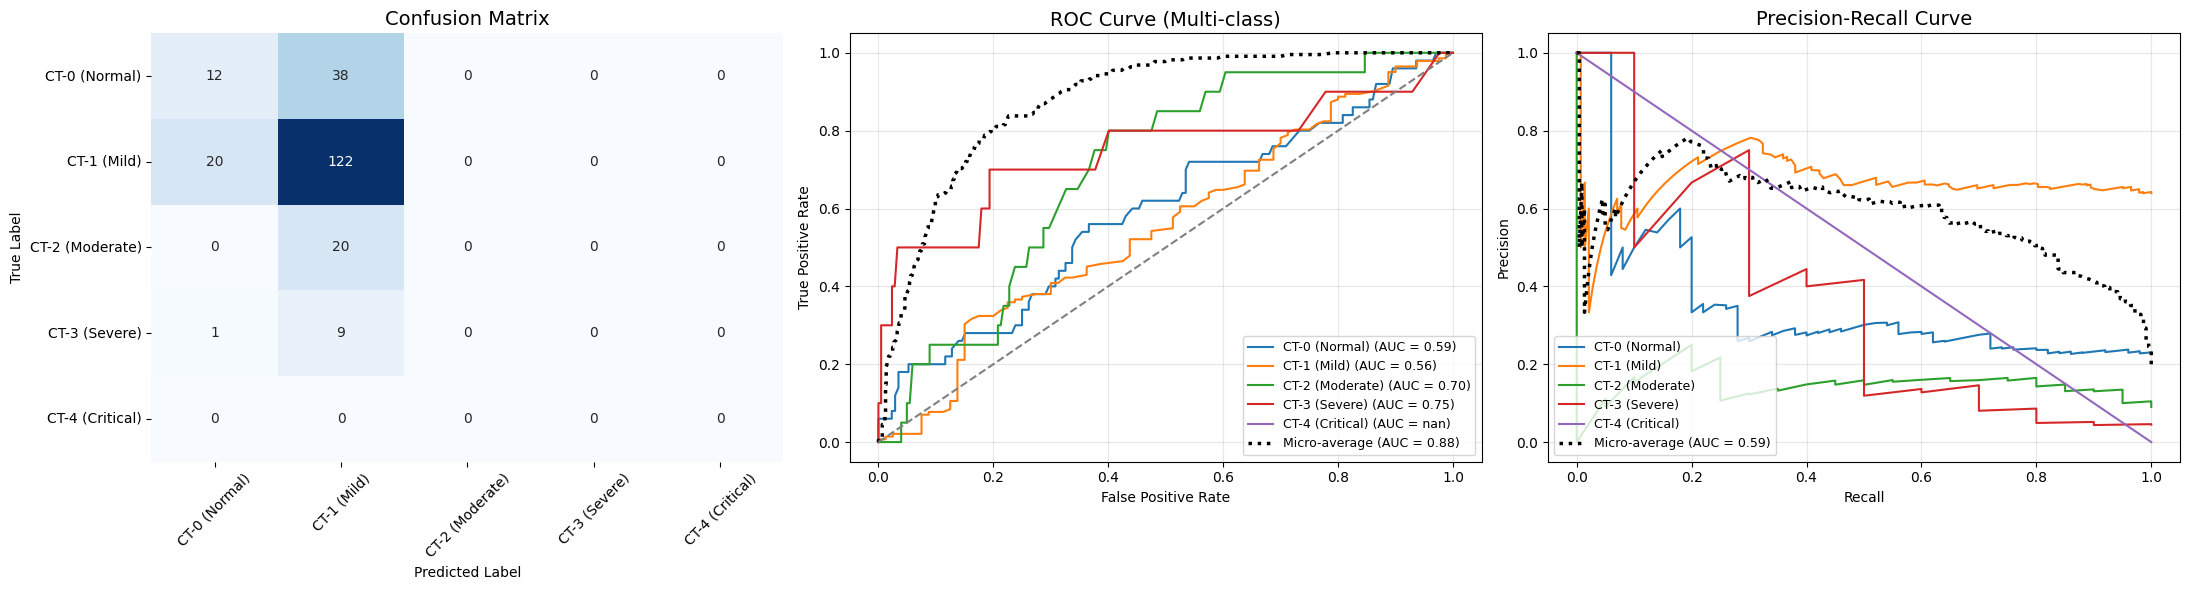

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Build and train the model
rf_classifier = RandomForestClassifier(n_estimators=500, random_state=42)
rf_classifier.fit(X_train_features_bal, y_train_bal)

# Predict classes and probabilities
y_pred_rf = rf_classifier.predict(X_test_features)
y_prob_rf = rf_classifier.predict_proba(X_test_features)

mosmed_classes = ['CT-0 (Normal)', 'CT-1 (Mild)', 'CT-2 (Moderate)', 'CT-3 (Severe)', 'CT-4 (Critical)']
print(">>> Random Forest Model Evaluation <<<")
evaluate_classifier_comprehensive(y_test, y_pred_rf, y_prob_rf, class_names=mosmed_classes)


> **Method 2: Deep Neural Network Classifier**
A small Multi-Layer Perceptron (MLP) with Dropout layers to classify the features.

🔍 در حال جستجوی بهترین نرخ یادگیری... (این مرحله کمی زمان می‌برد)


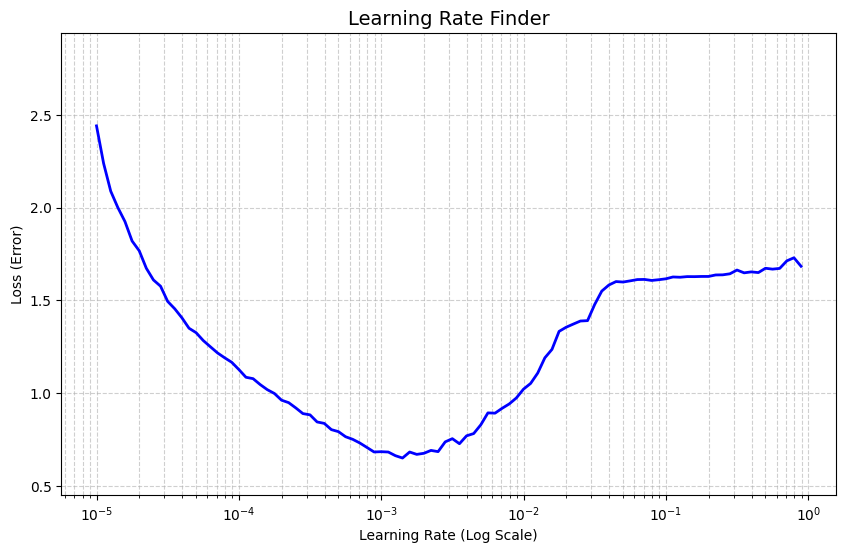

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import LearningRateScheduler
import matplotlib.pyplot as plt

# 1. Define a temporary model identical to the main one
lr_model = models.Sequential([
    layers.Input(shape=(256,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

# 2. Function to exponentially increase the learning rate each epoch
lr_schedule = LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch / 20))

# Compile with base learning rate
lr_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
                 loss='sparse_categorical_crossentropy', 
                 metrics=['accuracy'])

print("🔍 Searching for the best learning rate... (This might take a moment)")
# 3. Temporary training (100 epochs)
history_lr = lr_model.fit(
    X_train_features_bal, y_train_bal, 
    epochs=100, 
    batch_size=16, 
    callbacks=[lr_schedule],
    verbose=0 
)

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.semilogx(history_lr.history['learning_rate'], history_lr.history['loss'], lw=2, color='blue')
plt.title('Learning Rate Finder', fontsize=14)
plt.xlabel('Learning Rate (Log Scale)')
plt.ylabel('Loss (Error)')
plt.grid(True, which="both", ls="--", alpha=0.6)

# Limit Y-axis to prevent chart clutter on explosion
plt.ylim([min(history_lr.history['loss']) - 0.2, history_lr.history['loss'][0] + 0.5])
plt.show()


شروع آموزش شبکه دسته‌بند...
Epoch 1/300
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3514 - loss: 1.5914
Epoch 1: val_loss improved from None to 1.32259, saving model to best_classifier_nn.keras

Epoch 1: finished saving model to best_classifier_nn.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4100 - loss: 1.3644 - val_accuracy: 0.4144 - val_loss: 1.3226
Epoch 2/300
162/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4864 - loss: 1.1153
Epoch 2: val_loss improved from 1.32259 to 1.27595, saving model to best_classifier_nn.keras

Epoch 2: finished saving model to best_classifier_nn.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4878 - loss: 1.1086 - val_accuracy: 0.3919 - val_loss: 1.2760
Epoch 3/300
165/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5156 - loss: 1.0513
Epoch 3: val_loss improved from 1.27595 to 1.17923, saving model to best_classifier_nn.keras

Epoch 3: finished saving model to best_classifier_nn.keras
170/170 ━━━━━━━━━━━

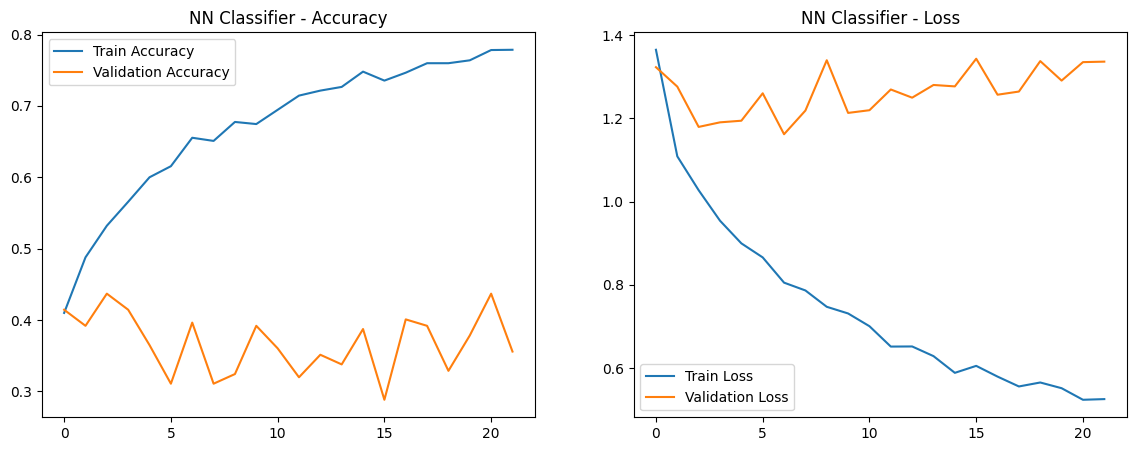

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
>>> ارزیابی مدل Neural Network <<<
 📊 گزارش جامع ارزیابی مدل (Classification Report)
                 precision    recall  f1-score   support

  CT-0 (Normal)     0.3231    0.4200    0.3652        50
    CT-1 (Mild)     0.6628    0.4014    0.5000       142
CT-2 (Moderate)     0.1579    0.3000    0.2069        20
  CT-3 (Severe)     0.1250    0.4000    0.1905        10
CT-4 (Critical)     0.0000    0.0000    0.0000         0

       accuracy                         0.3964       222
      macro avg     0.2538    0.3043    0.2525       222
   weighted avg     0.5166    0.3964    0.4293       222

 🎯 معیارهای کلان (Macro) و خرد (Micro)
Accuracy:                  0.3964
MCC:                       0.0987
------------------------------------------------------------
Precision (Macro):         0.2538
Precision (Micro):         0.3964
Recall (Macro):            0.3043
Recall (Micro):            0.3964
F1-Score (Macro):          0.2525
F1-Score (Micro):      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


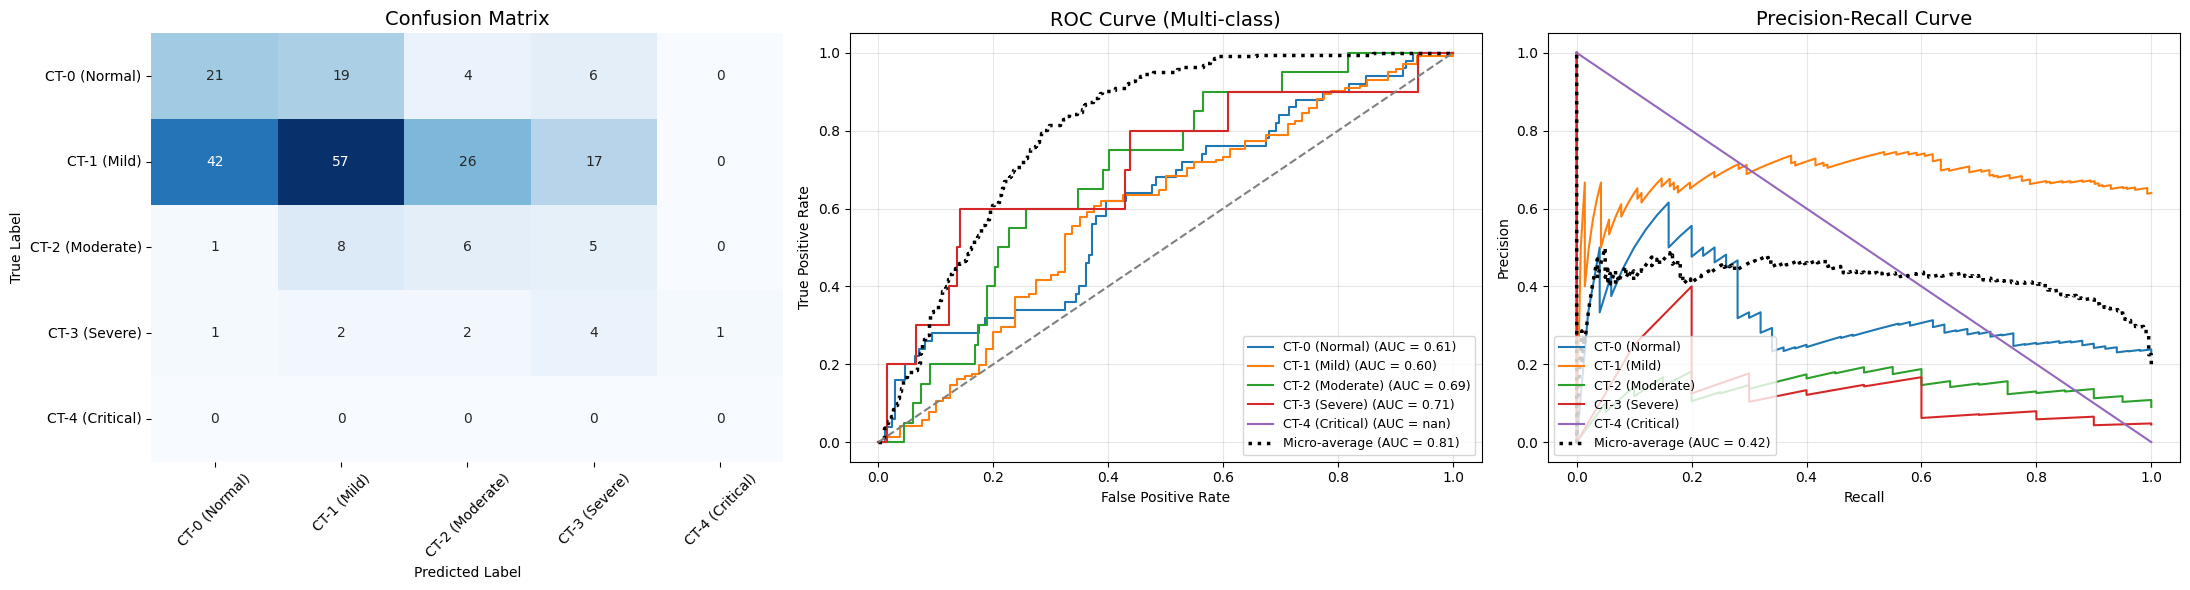

In [13]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

best_lr = 0.001 # Set based on the LR Finder chart

classifier_nn = models.Sequential([
    layers.Input(shape=(256,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

classifier_nn.compile(optimizer=Adam(learning_rate=best_lr), 
                      loss='sparse_categorical_crossentropy', 
                      metrics=['accuracy'])

# --- 1. Define Callbacks ---
clf_early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15,               # Stop if no improvement for 15 epochs
    restore_best_weights=True  # Restore best weights
)

clf_checkpoint = ModelCheckpoint(
    filepath='best_classifier_nn_tuned.keras', 
    monitor='val_loss', 
    save_best_only=True,       # Save only the best model
    verbose=1
)

# --- 2. Train the model ---
print("Starting Tuned Neural Network classifier training...")
history_clf = classifier_nn.fit(
    X_train_features_bal, y_train_bal, 
    epochs=300, 
    batch_size=16, 
    validation_data=(X_test_features, y_test),
    callbacks=[clf_early_stopping, clf_checkpoint], 
    verbose=1 
)

# Plot Training Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_clf.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_clf.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Tuned NN Classifier - Accuracy')
axes[0].legend()

axes[1].plot(history_clf.history['loss'], label='Train Loss')
axes[1].plot(history_clf.history['val_loss'], label='Validation Loss')
axes[1].set_title('Tuned NN Classifier - Loss')
axes[1].legend()
plt.show()

# Comprehensive Evaluation
y_prob_nn = classifier_nn.predict(X_test_features)
y_pred_nn = np.argmax(y_prob_nn, axis=1)

print(">>> Tuned Neural Network Classifier Evaluation <<<")
evaluate_classifier_comprehensive(y_test, y_pred_nn, y_prob_nn, class_names=mosmed_classes)
